In [2]:
import tarfile

with tarfile.open("/content/1774118365245-cv-corpus-25.0-2026-03-09-az.tar.gz", "r:gz") as tar:
    tar.extractall("common_voice_az")

/tmp/ipykernel_2788/2350319817.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("common_voice_az")


In [32]:
import os
import pandas as pd
from datasets import Dataset, Audio

DATA_DIR = "/content/common_voice_az/cv-corpus-25.0-2026-03-09/az/"
CLIPS_DIR = f"{DATA_DIR}/clips"

df = pd.read_csv(f"{DATA_DIR}/train.tsv", sep='\t')

df = df.sample(100, random_state=42).copy()

df['audio'] = df['path'].apply(lambda p: os.path.join(CLIPS_DIR, p))

df = df[['audio', 'sentence']]

dataset = Dataset.from_pandas(df)

dataset = dataset.cast_column("audio", Audio(sampling_rate=16_000))

dataset[99]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7efd7995ef60>,
 'sentence': 'Sosializmin bu ölkədə yaxşı adı olub.',
 '__index_level_0__': 122}

In [126]:
sample = dataset[3]

audio_array = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
text = sample["sentence"]


print(audio_array.shape)
print(sampling_rate)
print(text)

(72000,)
16000
Bir müddət sonra iki polis birlikdə axtarışa başlayır.


In [127]:
from IPython.display import Audio as IPythonAudio

IPythonAudio(audio_array, rate=sampling_rate)

In [57]:
import gradio as gr

def generate_audio():
    example = dataset.shuffle(seed=None)[0]
    audio = example['audio']

    return (
        audio['sampling_rate'],
        audio['array']
    ), example


with gr.Blocks() as demo:
    gr.Markdown("Common voice Azerbaijan")

    with gr.Column():
        for _ in range(4):
            audio, sentence = generate_audio()

            gr.Audio(value=audio, label="Audio")

demo.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d77326a463eee3064a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://fe8c5978aaa78b6934.gradio.live
Killing tunnel 127.0.0.1:7860 <> https://d77326a463eee3064a.gradio.live


Transcript:  Xalq təsərrüfatı üçün çox mühüm dövlət əhəmiyyəti olan belə problemə biganə qalmaq olmaz.
Sampling rate:  16000


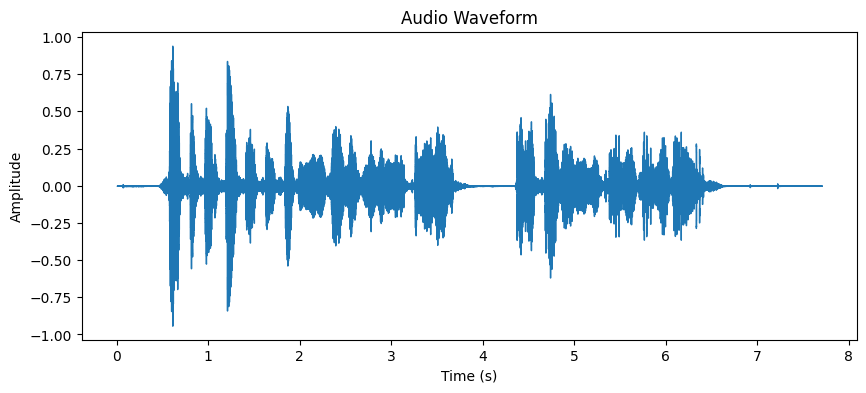

In [59]:
import librosa
import matplotlib.pyplot as plt

example = dataset[5]

array = example['audio']['array']
sampling_rate = example['audio']['sampling_rate']

print("Transcript: ", example['sentence'])
print("Sampling rate: ", sampling_rate)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(array, sr=sampling_rate)
plt.title('Audio Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

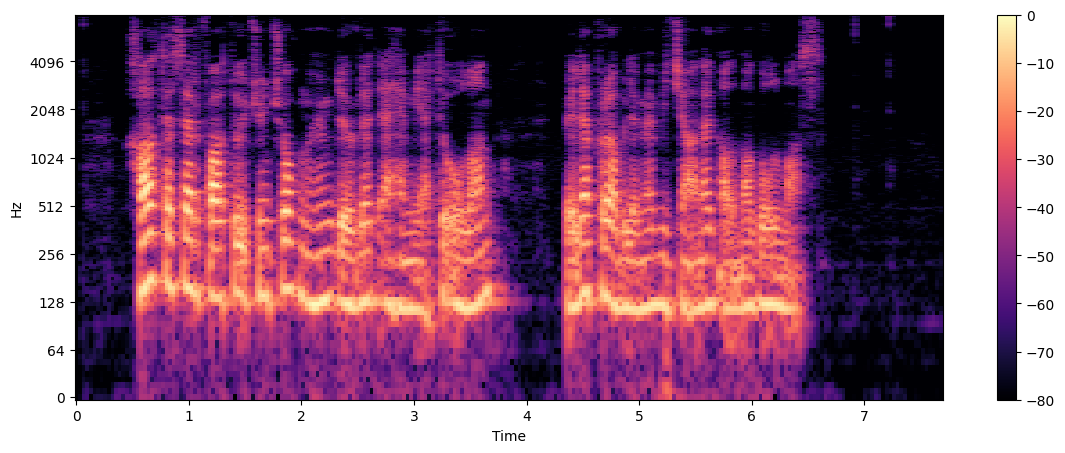

In [76]:
import numpy as np

D = librosa.stft(array)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sampling_rate, x_axis='time', y_axis='log')
plt.colorbar();

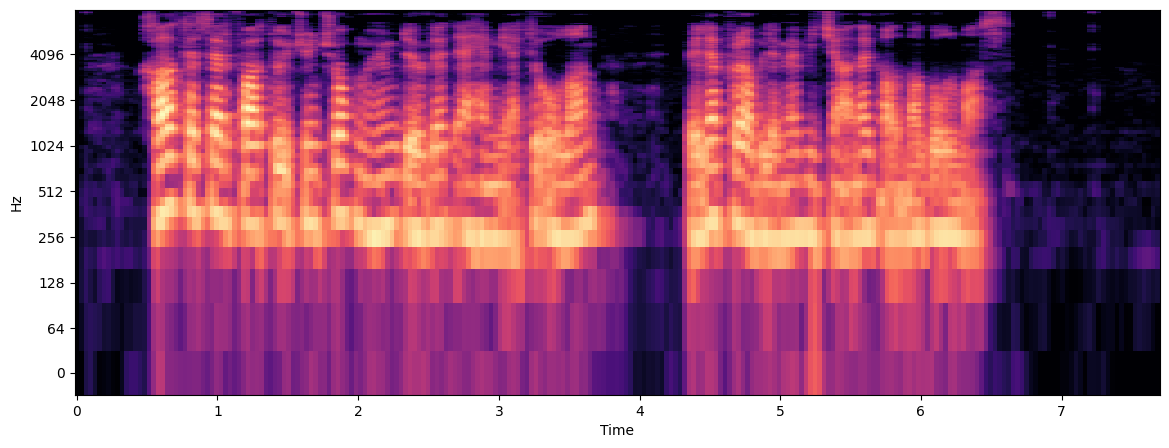

In [61]:
mel = librosa.feature.melspectrogram(
    y=array,
    sr=sampling_rate,
    n_mels=128,
    fmax=8000
)

mel_db = librosa.power_to_db(mel, ref=np.max)


plt.figure(figsize=(14, 5))
librosa.display.specshow(mel_db, sr=sampling_rate, x_axis='time', y_axis='log')
plt.show()

Index:  74
Text:  Yer Ayla Günəşin arasındadır.


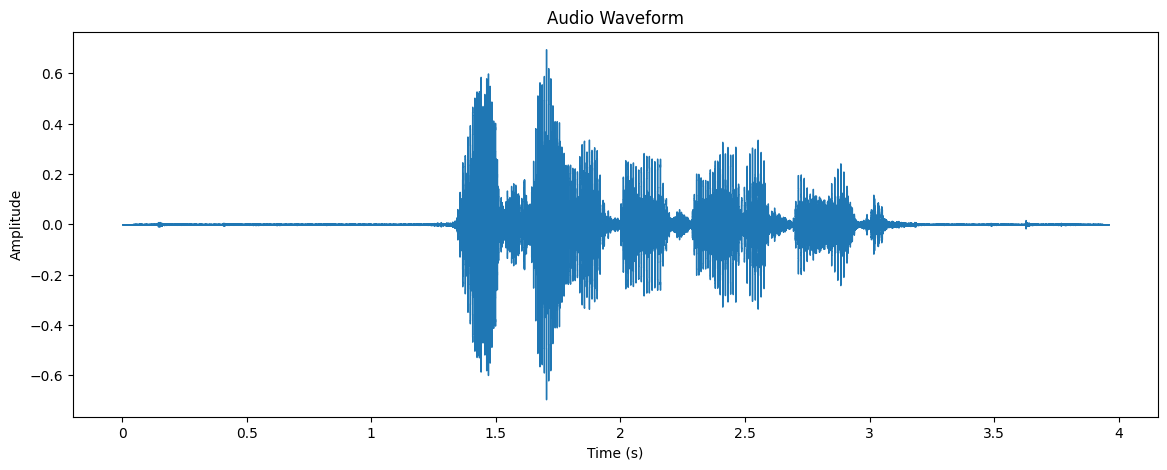

In [74]:
import random
from IPython.display import Audio as IPythonAudio, display

idx = random.randint(0, len(dataset) - 1)
example = dataset[idx]

audio = example['audio']
text = example['sentence']

print("Index: ", idx)
print("Text: ", text)
display(IPythonAudio(audio['array'], rate=audio['sampling_rate']))

plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio['array'], sr=audio['sampling_rate'])
plt.title('Audio Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

In [78]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = "openai/whisper-small"

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

model.eval()

print("Device: ", device)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Device:  cpu


In [87]:
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="az",
    task='transcribe'
)

In [88]:
predictions = []
references = []

for i, example in enumerate(dataset):
    audio = example['audio']

    input_features = processor(
        audio['array'],
        sampling_rate=audio['sampling_rate'],
        return_tensors='pt'
    ).input_features.to(device)

    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
            )

    pred_text = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    predictions.append(pred_text)
    references.append(example['sentence'])


    print(f"{i + 1}/{len(dataset)}")
    print(f'Prediction: {pred_text}')
    print(f'Reference: {example["sentence"]}')

1/100
Prediction:  Yəri çürəsinin başqa elimlər də öyrənir.
Reference: Yer kürəsini başqa elmlər də öyrənir.
2/100
Prediction:  Nəticədə agrar sektorun məhsul darlığı Azərbaycanın tarixində indiəq dəc bərabəri olmayan rekor təsdəcilərləmə çatmışdır.
Reference: Nəticədə aqrar sektorun məhsuldarlığı Azərbaycanın tarixində indiyədək bərabəri olmayan rekord göstəricilərinə çatmışdır.
3/100
Prediction:  Adətən mütləq dərinliyine görə ayrılır.
Reference: Adətən mütləq dərinliyinə görə ayrılır.
4/100
Prediction:  Bir müdə sonra iki polis birlikdə axtarışa başlayır.
Reference: Bir müddət sonra iki polis birlikdə axtarışa başlayır.
5/100
Prediction:  Səsin əxt olunmazsından nabıqəs eşilərin də də istibad olunur.
Reference: Səsin əks olunmasından naviqasiya işlərində də istifadə olunur.
6/100
Prediction:  Qalq təsərfatı üçün çox mühim dövlət əhəmiyyəti olan belə problemə bir cana qalmaq olmaz.
Reference: Xalq təsərrüfatı üçün çox mühüm dövlət əhəmiyyəti olan belə problemə biganə qalmaq olmaz.
7/

In [97]:
import re

def normalize_text(text):
    text = text.lower().strip()

    # keep Azerbaijani letters, numbers, and spaces
    text = re.sub(r"[^\w\səıöüçğş]", " ", text)

    # normalize multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


norm_predictions = [normalize_text(x) for x in predictions]
norm_references = [normalize_text(x) for x in references]

In [101]:
import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load('cer')

wer = wer_metrics.compute(predictions=norm_predictions, references=norm_references)
cer = cer_metric.compute(predictions=norm_predictions, references=norm_references)

print("WER: ", wer)
print("CER: ", cer)

WER:  0.5735694822888283
CER:  0.1530668631423835


In [102]:
from jiwer import wer, cer
import pandas as pd

rows = []

for i, (ref, pred, norm_ref, norm_pred) in enumerate(zip(references, predictions, norm_references, norm_predictions)):
    row = {
        'index': i,
        'reference': ref,
        'prediction': pred,
        'normalized_reference': norm_ref,
        'normalized_prediction': norm_pred,
        'wer': wer(norm_ref, norm_pred),
        'cer': cer(norm_ref, norm_pred)
    }

    rows.append(row)

results = pd.DataFrame(rows)
results = results.reset_index(drop=True).drop(columns=['index'])
results

,reference,prediction,normalized_reference,normalized_prediction,wer,cer
0,Yer kürəsini başqa elmlər də öyrənir.,Yəri çürəsinin başqa elimlər də öyrənir.,yer kürəsini başqa elmlər də öyrənir,yəri çürəsinin başqa elimlər də öyrənir,0.500000,0.138889
1,Nəticədə aqrar sektorun məhsuldarlığı Azərbayc...,Nəticədə agrar sektorun məhsul darlığı Azərba...,nəticədə aqrar sektorun məhsuldarlığı azərbayc...,nəticədə agrar sektorun məhsul darlığı azərbay...,0.583333,0.125000
2,Adətən mütləq dərinliyinə görə ayrılır.,Adətən mütləq dərinliyine görə ayrılır.,adətən mütləq dərinliyinə görə ayrılır,adətən mütləq dərinliyine görə ayrılır,0.200000,0.026316
3,Bir müddət sonra iki polis birlikdə axtarışa b...,Bir müdə sonra iki polis birlikdə axtarışa ba...,bir müddət sonra iki polis birlikdə axtarışa b...,bir müdə sonra iki polis birlikdə axtarışa baş...,0.125000,0.037736
4,Səsin əks olunmasından naviqasiya işlərində də...,Səsin əxt olunmazsından nabıqəs eşilərin də d...,səsin əks olunmasından naviqasiya işlərində də...,səsin əxt olunmazsından nabıqəs eşilərin də də...,0.750000,0.225806
...,...,...,...,...,...,...
95,Futbol federasiyasının qərarı ilə çempionat mü...,Futbol federa yasya sının qəlari ilə çempiyon...,futbol federasiyasının qərarı ilə çempionat mü...,futbol federa yasya sının qəlari ilə çempiyona...,0.857143,0.173913
96,Bir çox şəhər və qalanın itirilməsi xəbəri pay...,Bir çox şəhər və qalanını içəyilməsi xəbəri p...,bir çox şəhər və qalanın itirilməsi xəbəri pay...,bir çox şəhər və qalanını içəyilməsi xəbəri pa...,0.266667,0.066038
97,Stadionun dizaynı Toyota şəhərindəki Toyota St...,Stadionun dizani Toyota şəhərindəki Toyota St...,stadionun dizaynı toyota şəhərindəki toyota st...,stadionun dizani toyota şəhərindəki toyota sta...,0.400000,0.102273
98,Onun oğlu Məlik Məhəmməd xanın hakimiyyəti döv...,"Onun oğlu Mərəkmənməq, hənin hakimətə dövdün ...",onun oğlu məlik məhəmməd xanın hakimiyyəti döv...,onun oğlu mərəkmənməq hənin hakimətə dövdün də...,0.818182,0.302326


In [103]:
pd.set_option('display.max_colwidth', None)
best_5 = results.sort_values(by='wer', ascending=True).head(5)
best_5

,reference,prediction,normalized_reference,normalized_prediction,wer,cer
49,Divarlar üç sıra kərpic və bir sıra çay daşından hörülmüşdür.,Divarlar üç sıra kərpic və bir sıra çay daşından hörülmüşdür.,divarlar üç sıra kərpic və bir sıra çay daşından hörülmüşdür,divarlar üç sıra kərpic və bir sıra çay daşından hörülmüşdür,0.000000,0.000000
33,Bu suları Laçın və ətraf rayonların əhalisi özləri üçün sevimli müalicəvi vasitə sayırlar.,Bu suları laçın və ətraf rayonların əhalisi özləri üçün sevimli müalicəvi vaxtə sayırlar.,bu suları laçın və ətraf rayonların əhalisi özləri üçün sevimli müalicəvi vasitə sayırlar,bu suları laçın və ətraf rayonların əhalisi özləri üçün sevimli müalicəvi vaxtə sayırlar,0.076923,0.022472
9,Alətin alt hissəsində onu yerə qoymaq üçün iti bir çıxıntı olur.,Alətin alt hissəsində onu yerə qoymak üçün iti bir çıxıntı olur.,alətin alt hissəsində onu yerə qoymaq üçün iti bir çıxıntı olur,alətin alt hissəsində onu yerə qoymak üçün iti bir çıxıntı olur,0.090909,0.015873
3,Bir müddət sonra iki polis birlikdə axtarışa başlayır.,Bir müdə sonra iki polis birlikdə axtarışa başlayır.,bir müddət sonra iki polis birlikdə axtarışa başlayır,bir müdə sonra iki polis birlikdə axtarışa başlayır,0.125000,0.037736
15,Midiyalılar barəsində yunanlar məlumat verməyə başladı.,Medialar barəsində Yunanlar məlumat verməyə başladı.,midiyalılar barəsində yunanlar məlumat verməyə başladı,medialar barəsində yunanlar məlumat verməyə başladı,0.166667,0.074074


In [104]:
worst_5 = results.sort_values(by='wer', ascending=False).head(5)
worst_5


,reference,prediction,normalized_reference,normalized_prediction,wer,cer
56,Dərisi hamardır.,Dərisə hama artır.,dərisi hamardır,dərisə hama artır,1.500000,0.266667
50,Uizli ailəsinin evi.,"Bu izlə, ailəsin nəvi.",uizli ailəsinin evi,bu izlə ailəsin nəvi,1.333333,0.315789
20,Maksim karyerasına Qarabağda başlayıb.,Maxim kariyer asməl qara baxda başlayıb.,maksim karyerasına qarabağda başlayıb,maxim kariyer asməl qara baxda başlayıb,1.250000,0.243243
30,Kəşfiyyatçı atıcı idi.,Çəşfiyat-cət-cidi.,kəşfiyyatçı atıcı idi,çəşfiyat cət cidi,1.000000,0.428571
37,Qoruğun bitki örtüyü zəngin deyil.,"Qorgun bitiyor, tüz əncində il.",qoruğun bitki örtüyü zəngin deyil,qorgun bitiyor tüz əncində il,1.000000,0.393939
